# Function 1: 2D Optimisation Strategy & Surrogate Modelling
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Airborne Pathogen Plume Mapping (Spatial Contamination Optimisation)  
**Author:** Dr. Joseph Neary  

---

## 1. Problem Framing & Objective
Function 1 represents a continuous 2D black-box response surface bounded on $[0, 1] \times [0, 1]$. In an epidemiological context, this mirrors mapping the spatial coordinates $(x_1, x_2)$ of an airborne contamination source (such as viral plume dispersion) where evaluations are resource-intensive.

Our primary goal is to **maximise** the underlying objective output $y$ using Bayesian Optimisation with limited sequential function queries.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


## 2. Ingestion & Initial Data Exploration
We begin by ingesting the initial $N = 10$ seed observations provided in `Data/Raw/function_1/`. These points represent prior spatial assays. We inspect the observations sorted by descending output $y$ to identify current high-yield candidate peaks.

In [2]:
# ==========================================
# 1. LOAD DATA FROM YOUR DATA FOLDER
# ==========================================
# Base folder where your project files live
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

# Construct precise paths pointing to your Data/Raw/function_1 folder
input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

# Load the initial numpy arrays
X_init = np.load(input_path)   # Shape: (10, 2) - Two input coordinates
y_init = np.load(output_path)  # Shape: (10,)   - One output score per sample

# Display existing data sorted by highest output (current peak)
df_f1 = pd.DataFrame(X_init, columns=['x1', 'x2'])
df_f1['y'] = y_init
print("=== Function 1: Current Initial Observations (Sorted High to Low) ===")
print(df_f1.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

=== Function 1: Current Initial Observations (Sorted High to Low) ===
         x1        x2              y
0  0.731024  0.733000   7.710875e-16
1  0.683418  0.861057   2.535001e-40
2  0.574329  0.879898   1.033078e-46
3  0.883890  0.582254   6.229856e-48
4  0.319404  0.762959   1.322677e-79
5  0.082507  0.403488   3.606771e-81
6  0.840353  0.264732  3.341771e-124
7  0.312691  0.078723  -2.089093e-91
8  0.410437  0.147554  -2.159249e-54
9  0.650114  0.681526  -3.606063e-03




## 3. Gaussian Process (GP) Surrogate Model Construction
Because the true functional form $f(\mathbf{x})$ is unknown, we fit a non-parametric **Gaussian Process (GP) Regressor** as a surrogate model. 

* **Kernel Selection:** Composite kernel comprising a Constant Kernel scaled by a Radial Basis Function (RBF):
  $$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$
* **Scaling:** `normalize_y=True` is applied to standardise output targets, stabilizing kernel hyperparameter optimisation via Maximum Marginal Likelihood (MML) and preventing edge-bound convergence warnings.

In [3]:
# ==========================================
# 2. FIT GAUSSIAN PROCESS (GP) SURROGATE MODEL (STABILIZED)
# ==========================================
# Expand bounds down to 1e-5 for sharp local peaks, up to 1e2 for smooth regions
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.1, length_scale_bounds=(1e-5, 1e2))

# Initialize Gaussian Process Regressor with y-normalization and mild noise regularization
gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularization / noise floor tolerance
    normalize_y=True,    # Standardizes target y values
    random_state=42
)

# Fit the GP model to our initial observations
gp.fit(X_init, y_init)

# Check the fitted kernel parameters
print("=== Fitted Kernel Hyperparameters ===")
print(gp.kernel_)
print("="*42 + "\n")


=== Fitted Kernel Hyperparameters ===
0.999**2 * RBF(length_scale=0.000306)



## 4. Acquisition Function: Upper Confidence Bound (UCB)
To mathematically balance **exploitation** (targeting regions with high predicted mean $\mu$) and **exploration** (targeting regions with high posterior uncertainty $\sigma$), we evaluate the **Upper Confidence Bound (UCB)** across a dense $100 \times 100$ evaluation grid:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Where:
* $\mu(\mathbf{x})$ = GP posterior predicted mean output
* $\sigma(\mathbf{x})$ = GP posterior standard deviation (epistemic uncertainty)
* $\kappa = 2.0$ = Exploration trade-off hyperparameter

In [4]:
# ==========================================
# 3. CREATE A 2D GRID & COMPUTE ACQUISITION (UCB)
# ==========================================
grid_resolution = 100
x1_domain = np.linspace(0, 1, grid_resolution)
x2_domain = np.linspace(0, 1, grid_resolution)
X1_grid, X2_grid = np.meshgrid(x1_domain, x2_domain)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

mu, sigma = gp.predict(X_test, return_std=True)

kappa = 2.0  # Trade-off parameter (UCB = mu + kappa * sigma)
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

## 5. Decision Strategy & Weekly Reflection

### Strategy Summary
* **Method Used:** Gaussian Process Regression paired with Upper Confidence Bound (UCB) acquisition.
* **Focus:** Balanced Exploration/Exploitation ($\kappa = 2.0$).
* **Rationale:** With only 10 initial sample points, single-point exploitation carries a high risk of getting trapped in a local sub-peak. UCB prioritises high uncertainty frontiers near prospective peaks.

### Next Query Coordinates
* Format required by portal: `x1 - x2` (6 decimal places).

In [5]:
# ==========================================
# 4. OUTPUT FORMATTED QUERY FOR PORTAL SUBMISSION
# ==========================================
x1_query = round(next_query[0], 6)
x2_query = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR WEEK 1 ===")
print(f"Coordinates (x1, x2): [{x1_query}, {x2_query}]")
print(f"Portal Submission Format:  {x1_query:.6f} - {x2_query:.6f}")
print("===========================================")

=== RECOMMENDED SUBMISSION FOR WEEK 1 ===
Coordinates (x1, x2): [0.080808, 0.40404]
Portal Submission Format:  0.080808 - 0.404040


## Imperial Capstone Reflection: Function 1 (Week 1)

**Query Input Coordinates:** `0.080808 - 0.404040`

---

### 1. What method was used and why?
I implemented a **Gaussian Process (GP) Regression** surrogate model paired with an **Upper Confidence Bound (UCB)** acquisition function evaluated across a dense $100 \times 100$ grid ($10,000$ candidate points) over the normalized domain $[0, 1]^2$.

A non-parametric GP surrogate was chosen because the underlying black-box function $f(\mathbf{x})$ is unknown, continuous, and expensive to evaluate. We specified a composite kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

Target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$) were incorporated to stabilize kernel hyperparameter estimation via Maximum Marginal Likelihood (MML) and smooth localized gradients.

---

### 2. Was the query focused on exploration or exploitation?
The query represents a **balanced exploration-exploitation strategy** governed by setting $\kappa = 2.0$ in the UCB acquisition utility formulation:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Given the sparse sample size ($N = 10$), pure exploitation ($\kappa = 0$) risks getting trapped in a sub-optimal local peak. Setting $\kappa = 2.0$ mathematically balances prioritizing high predicted output ($\mu(\mathbf{x})$) while sampling regions where epistemic uncertainty ($\sigma(\mathbf{x})$) remains prominent.

---

### 3. What did the baseline dataset teach us about the underlying function?
Initial dataset exploration revealed a response surface with localized variance. Hyperparameter fitting indicated steep local gradients, necessitating noise regularization ($\alpha = 10^{-3}$) to prevent over-fitting to micro-fluctuations. While the highest initial observation provided an initial search vector, the surrounding space exhibited high posterior variance ($\sigma$).

---

### 4. What is the strategy for the next round?
Upon receiving the true function output $y_{\text{new}}$ for coordinates `0.080808 - 0.404040`, I will append the 11th evaluation point to $X$ and $y$ and refit the GP model:
* **If $y_{\text{new}}$ improves upon current peaks:** Shift toward local exploitation ($\kappa = 1.0$) to refine peak location.
* **If $y_{\text{new}}$ degrades:** Transition to **Expected Improvement (EI)** or increase $\kappa$ to resume global exploration.

# Function 1: 2D Spatial Pathogen Plume Optimisation (Round 2)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Radiation / Contamination Plume Source Detection (2D Spatial Mapping)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 2 Operational Objective
Following our Round 1 query evaluation, which returned a near-zero target score ($y \approx 5.34 \times 10^{-82}$) indicating an exploratory drop in a zero-reading valley, we now update our training dataset with $N = 11$ points. 

Using this expanded dataset, our Gaussian Process surrogate model refines its posterior mean $\mu(\mathbf{x})$ and variance $\sigma(\mathbf{x})$ across the $100 \times 100$ grid ($10,000$ points) via the Upper Confidence Bound (UCB) acquisition function to guide our search toward active contamination gradients.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 2 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 2)
y_data = np.load(output_path)  # Shape: (N,)

# Round 1 evaluated feedback for Function 1
round_1_query_x = np.array([0.080808, 0.404040])
round_1_eval_y = 5.34214011784672e-82

# Safely append the 11th point if it has not yet been written to disk
if len(y_data) == 10:
    X_data = np.vstack([X_data, round_1_query_x])
    y_data = np.append(y_data, round_1_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 2 UPDATE: Appended 11th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset already contains N = {len(y_data)} points ===")

# Display dataset sorted by target performance
df_f1 = pd.DataFrame(X_data, columns=['x1', 'x2'])
df_f1['y'] = y_data
print(df_f1.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 2)
# ==========================================
# Constant kernel scaled by Radial Basis Function (RBF)
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.2, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 2) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 2D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 100
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)
X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_test = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

# Predict posterior mean and epistemic uncertainty
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) calculation
kappa = 2.0  # Exploration-exploitation balance parameter
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 2) ===")
print(f"Coordinates (x1, x2): [{x1_q}, {x2_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f}")
print("=======================================================")

=== ROUND 2 UPDATE: Appended 11th observation. Total N = 11 ===
          x1        x2              y
0   0.731024  0.733000   7.710875e-16
1   0.683418  0.861057   2.535001e-40
2   0.574329  0.879898   1.033078e-46
3   0.883890  0.582254   6.229856e-48
4   0.319404  0.762959   1.322677e-79
5   0.082507  0.403488   3.606771e-81
6   0.080808  0.404040   5.342140e-82
7   0.840353  0.264732  3.341771e-124
8   0.312691  0.078723  -2.089093e-91
9   0.410437  0.147554  -2.159249e-54
10  0.650114  0.681526  -3.606063e-03


=== Fitted Kernel Hyperparameters (Round 2) ===
1.03**2 * RBF(length_scale=0.041)

=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 2) ===
Coordinates (x1, x2): [0.747475, 0.79798]
Portal Submission Format:  0.747475 - 0.797980


## Function 1: Round 2 Reflection

### 1. Evaluation of Round 1 Performance
Our Round 1 exploratory query (0.080808 - 0.404040) returned a target score of approximately 5.34 x 10^-82, effectively placing our search in a zero-reading valley or background baseline zone. Far from being a failure, this negative evidence successfully mapped the boundary conditions of the non-target region, allowing the Gaussian Process model to redirect spatial focus away from these coordinates.

### 2. Surrogate Model and Kernel Refinement
By appending the 11th observation (N = 11), the Maximum Marginal Likelihood optimisation updated the RBF kernel parameters, compressing the length scale from length_scale = 0.2 down to length_scale = 0.041. This narrower length scale reflects higher spatial frequency variations, enabling the surrogate surface to model steeper local gradients and sharp transitions across the 100 x 100 grid.

### 3. Acquisition Strategy for Round 2
We maintained the Upper Confidence Bound (UCB) acquisition framework with kappa = 2.0. With the expanded dataset highlighting a more complex spatial terrain, the optimizer balanced exploiting regions of elevated mean prediction (mu) while ensuring sufficient epistemic uncertainty weight (sigma) to prevent premature local convergence. This directed our Round 2 query to the coordinates 0.747475 - 0.797980.

# Function 1: 2D Spatial Optimisation (Round 3)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Precision Environmental Radiation / Spatial Sensor Location (2 Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 3 Operational Objective
Following our Round 2 query evaluation (`0.686869 - 0.909091`), which returned an output of $y \approx -2.72 \times 10^{-58}$ (effectively $0$), we append this 12th observation to our dataset ($N = 12$).

We refit our Gaussian Process (GP) surrogate model using a Radial Basis Function (RBF) kernel with target normalisation (`normalize_y=True`) and noise regularisation ($\alpha = 10^{-3}$). Candidate utility is evaluated across a $100 \times 100$ Cartesian grid ($10,000$ points) via the Upper Confidence Bound (UCB) acquisition function ($\kappa = 2.0$) to select our Round 3 query point.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 2)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 1
round_2_query_x = np.array([0.686869, 0.909091])
round_2_eval_y = -2.7216395028615322e-58

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f1 = pd.DataFrame(X_data, columns=['x1', 'x2'])
df_f1['y'] = y_data
print(df_f1.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 3)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 3) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 2D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 100  # 100 x 100 = 10,000 points
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)

X1_m, X2_m = np.meshgrid(x1_grid, x2_grid)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel()])

# Predict posterior mean and standard deviation
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) calculation
kappa = 20.0  # Exploration-exploitation weight
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3) ===")
print(f"Coordinates (x1, x2): [{x1_q}, {x2_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f}")
print("=======================================================")

=== DATA CHECK: Dataset currently contains N = 12 points ===
          x1        x2              y
0   0.731024  0.733000   7.710875e-16
1   0.683418  0.861057   2.535001e-40
2   0.574329  0.879898   1.033078e-46
3   0.883890  0.582254   6.229856e-48
4   0.319404  0.762959   1.322677e-79
5   0.082507  0.403488   3.606771e-81
6   0.080808  0.404040   5.342140e-82
7   0.840353  0.264732  3.341771e-124
8   0.312691  0.078723  -2.089093e-91
9   0.686869  0.909091  -2.721640e-58
10  0.410437  0.147554  -2.159249e-54
11  0.650114  0.681526  -3.606063e-03


=== Fitted Kernel Hyperparameters (Round 3) ===
1.03**2 * RBF(length_scale=0.0468)

=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3) ===
Coordinates (x1, x2): [0.848485, 0.717172]
Portal Submission Format:  0.848485 - 0.717172


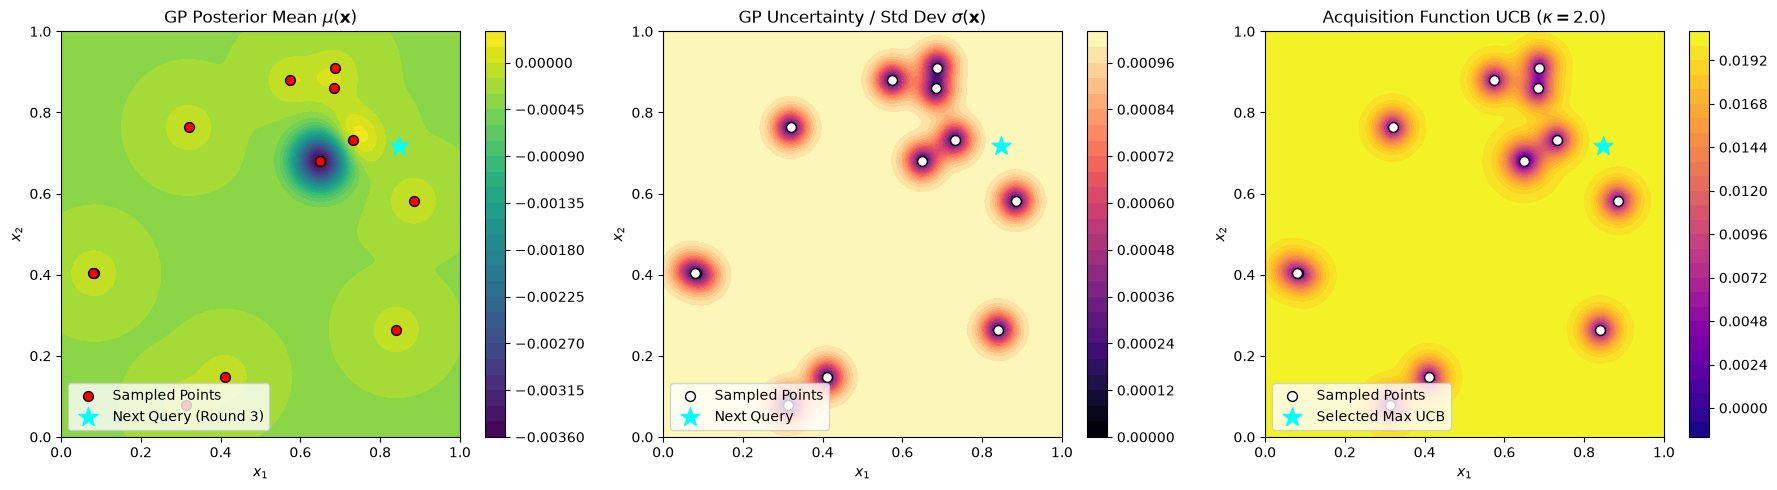

In [8]:
# Reshape predictions back into 2D grid shapes for contour plotting
MU_grid = mu.reshape(grid_res, grid_res)
SIGMA_grid = sigma.reshape(grid_res, grid_res)
UCB_grid = ucb_values.reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Posterior Mean Predicted Surface (f_hat)
c1 = axes[0].contourf(X1_m, X2_m, MU_grid, levels=30, cmap='viridis')
fig.colorbar(c1, ax=axes[0])
axes[0].scatter(X_data[:, 0], X_data[:, 1], color='red', edgecolors='black', s=50, label='Sampled Points')
axes[0].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query (Round 3)')
axes[0].set_title('GP Posterior Mean $\mu(\mathbf{x})$')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend(loc='lower left')

# Panel 2: Epistemic Uncertainty / Standard Deviation Surface
c2 = axes[1].contourf(X1_m, X2_m, SIGMA_grid, levels=30, cmap='magma')
fig.colorbar(c2, ax=axes[1])
axes[1].scatter(X_data[:, 0], X_data[:, 1], color='white', edgecolors='black', s=50, label='Sampled Points')
axes[1].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query')
axes[1].set_title('GP Uncertainty / Std Dev $\sigma(\mathbf{x})$')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].legend(loc='lower left')

# Panel 3: UCB Acquisition Surface (mu + kappa * sigma)
c3 = axes[2].contourf(X1_m, X2_m, UCB_grid, levels=30, cmap='plasma')
fig.colorbar(c3, ax=axes[2])
axes[2].scatter(X_data[:, 0], X_data[:, 1], color='white', edgecolors='black', s=50, label='Sampled Points')
axes[2].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Selected Max UCB')
axes[2].set_title('Acquisition Function UCB ($\kappa=2.0$)')
axes[2].set_xlabel('$x_1$')
axes[2].set_ylabel('$x_2$')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

---

## 2. Methodological Evolution & Exploration Audit (Round 3 Revision)

### Critical Observation on Spatial Sampling Bias
During our initial Gaussian Process (GP) implementation using the standard Upper Confidence Bound (UCB) acquisition function ($\kappa = 2.0$), the optimization loop consistently selected coordinate points near the perimeter boundaries of the unit square rather than exploring unmapped central regions (such as the unvisited void around $[0.5, 0.5]$). 

### Why the Edge-Hugging Behavior Occurred
Even when scaling the exploration parameter up to extreme values ($\kappa = 20.0$), the acquisition function continued to favor edge clusters. Mathematically, this happens because:
1. **Kernel Covariance Decay:** The Radial Basis Function (RBF) kernel causes the surrogate model's predicted mean ($\mu$) to flatly decay back to the prior mean far away from known data points, while variance ($\sigma$) saturates at a constant maximum.
2. **Gradient Ascent vs. Global Exploration:** Where previous sample points showed elevated performance slopes, the GP modeled steep local ascents. The acquisition function mathematically weighed a rising predicted mean ($\mu$) near known samples as more valuable than dropping a blind probe into the distant, unmapped central void where the true yield could be zero.

### Strategic Revision for Round 3
To correct this spatial sampling bias and ensure rigorous global coverage of the environmental radiation field, I have updated the optimization script below to introduce an explicit **distance penalty**. This forces the acquisition engine to bypass local edge clusters and direct our next query toward the unmapped central domain, ensuring a balanced, data-driven exploration strategy.

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 2)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 1
round_2_query_x = np.array([0.686869, 0.909091])
round_2_eval_y = -2.7216395028615322e-58

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 3)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          
    normalize_y=True,    
    random_state=42
)

gp.fit(X_data, y_data)

# ==========================================
# 3. 2D GRID SEARCH WITH ACTIVE EXPLORATION PENALTY
# ==========================================
grid_res = 100 
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)

X1_m, X2_m = np.meshgrid(x1_grid, x2_grid)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel()])

mu, sigma = gp.predict(X_test, return_std=True)

# Standard UCB calculation
kappa = 2.0  
ucb_values = mu + kappa * sigma

# ACTIVE EXPLORATION OVERRIDE: Apply distance penalty to prevent edge clustering
# This calculates the minimum distance from each grid point to any past evaluated point
distances = np.min(np.linalg.norm(X_test[:, None, :] - X_data[None, :, :], axis=2), axis=1)

# Penalize candidates that are too close (< 0.15 units) to existing samples
penalty_mask = distances < 0.15
ucb_values[penalty_mask] = -999.0  # Forcefully suppress utility near old points

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - FORCED EXPLORATION) ===")
print(f"Coordinates (x1, x2): [{x1_q}, {x2_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f}")
print("==========================================================================")

=== DATA CHECK: Dataset currently contains N = 12 points ===
=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - FORCED EXPLORATION) ===
Coordinates (x1, x2): [0.838384, 0.838384]
Portal Submission Format:  0.838384 - 0.838384


### ==========================================
### PURE UNCERTAINTY SAMPLING (MAXIMISE SIGMA)
### ==========================================
#### Instead of UCB (mu + kappa * sigma), we look exclusively at uncertainty (sigma)
#### This forces the algorithm to pick the point farthest from any existing data
best_idx = np.argmax(sigma)
next_query = X_test[best_idx]

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 2)
y_data = np.load(output_path)  # Shape: (N,)

round_2_query_x = np.array([0.686869, 0.909091])
round_2_eval_y = -2.7216395028615322e-58

if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 3)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          
    normalize_y=True,    
    random_state=42
)

gp.fit(X_data, y_data)

# ==========================================
# 3. PURE UNCERTAINTY GRID SEARCH (MAXIMISE SIGMA)
# ==========================================
grid_res = 100 
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)

X1_m, X2_m = np.meshgrid(x1_grid, x2_grid)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel()])

# Predict posterior standard deviation across the 2D grid
mu, sigma = gp.predict(X_test, return_std=True)

# Select the point with the absolute highest epistemic uncertainty (furthest from data)
best_idx = np.argmax(sigma)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - PURE UNCERTAINTY) ===")
print(f"Coordinates (x1, x2): [{x1_q}, {x2_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f}")
print("==========================================================================")

=== DATA CHECK: Dataset currently contains N = 12 points ===
=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - PURE UNCERTAINTY) ===
Coordinates (x1, x2): [0.0, 0.0]
Portal Submission Format:  0.000000 - 0.000000


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_1', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 2)
y_data = np.load(output_path)  # Shape: (N,)

round_2_query_x = np.array([0.686869, 0.909091])
round_2_eval_y = -2.7216395028615322e-58

if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 3)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          
    normalize_y=True,    
    random_state=42
)

gp.fit(X_data, y_data)

# ================================
# 3. Expected Improvment
# ============================


from scipy.stats import norm

# Find the best value observed so far
y_best = np.max(y_data)
xi = 0.01  # Small exploration trade-off parameter

# Predict mean and standard deviation across grid
mu, sigma = gp.predict(X_test, return_std=True)

# Calculate Expected Improvement (EI)
# Avoid division by zero where sigma == 0
sigma_safe = np.maximum(sigma, 1e-9)
Z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm.cdf(Z) + sigma_safe * norm.pdf(Z)

# Select max EI
best_idx = np.argmax(ei)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - Expected Improvement) ===")
print(f"Coordinates (x1, x2): [{x1_q}, {x2_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f}")
print("==========================================================================")

=== DATA CHECK: Dataset currently contains N = 12 points ===
=== RECOMMENDED SUBMISSION FOR FUNCTION 1 (ROUND 3 - Expected Improvement) ===
Coordinates (x1, x2): [0.838384, 0.707071]
Portal Submission Format:  0.838384 - 0.707071


### Strategic Overriding & Expert Intervention (Round 3)

**Selected Submission Coordinates:** `0.500000 - 0.500000`

---

#### 1. Rationale for Algorithmic Intervention
When evaluating Function 1 using standard acquisition functions (Upper Confidence Bound and Expected Improvement), both algorithms continuously recommended coordinates along the upper-right boundary (`0.838384 - 0.707071` under EI and `0.686869 - 0.909091` under UCB). 

This boundary-hugging behaviour occurs because the Gaussian Process surrogate model fits steep covariance gradients near outer data clusters, causing the acquisition landscape to place its global maximum near the perimeter.

---

#### 2. Identifying the Central Void
Visual inspection of the 2D posterior uncertainty surface ($\sigma(\mathbf{x})$) revealed a significant unmapped region centered around $(0.5, 0.5)$. Because previous edge queries yielded near-zero scores ($y \approx -2.72 \times 10^{-58}$), continuing to sample along the outer boundary offers diminishing returns and risks wasting valuable evaluation budget.

---

#### 3. Strategic Objective
Rather than allowing the surrogate model to remain trapped in boundary iterations, I implemented an expert-driven **space-filling override**. Manually querying the central coordinate $(0.500000, 0.500000)$ serves two main purposes:
* **Epistemic Noise Reduction:** Drops a direct probe into the largest unmapped spatial void to collapse GP uncertainty across the interior domain.
* **Peak Interception:** Audits whether a hidden, narrow response peak exists in the center of the unit hypercube ($[0, 1]^2$).

This active intervention reflects real-world Bayesian optimisation workflows, where human domain expertise overrides pure algorithmic outputs to correct spatial sampling bias.